In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
num_feature_directory = "../Num_Features/"

In [3]:
# Initialize an empty list to store individual DataFrames
dataframes = []
experiments = []

for filename in os.listdir(num_feature_directory):
    if filename.endswith("features_selected.csv"):
        # Construct the full file path
        file_path = os.path.join(num_feature_directory, filename)
        experiment_name = filename.split("_")[0]
        experiments.append(experiment_name)
        
        df = pd.read_csv(file_path)
        df['experiment'] = experiment_name + "_" + df["celltype"]
        
        dataframes.append(df)

In [4]:
combined_df = pd.concat(dataframes, axis=0)
combined_df

,celltype,num_features,experiment
0,mesenchymal stem cell,8192,Limb-Muscle_mesenchymal stem cell
1,endothelial cell,8,Limb-Muscle_endothelial cell
2,macrophage,8192,Limb-Muscle_macrophage
3,skeletal muscle satellite cell,8192,Limb-Muscle_skeletal muscle satellite cell
4,smooth muscle cell,8192,Limb-Muscle_smooth muscle cell
5,T cell,8192,Limb-Muscle_T cell
6,B cell,8192,Limb-Muscle_B cell
0,endothelial cell,8192,Lung_endothelial cell
1,stromal cell,8192,Lung_stromal cell
2,lymphocyte,4096,Lung_lymphocyte


In [5]:
combined_df["experiment"] = combined_df["experiment"].replace({
    "Kidney_kidney loop of Henle thick ascending limb epithelial cell": "Kidney TAL epith cell",
    "Bone-Marrow_megakaryocyte-erythroid progenitor cell": "Bone-Marrow MEP cell",
    "Kidney_kidney proximal convoluted tubule epithelial cell": "Kidney_PCT_epith cell"
})

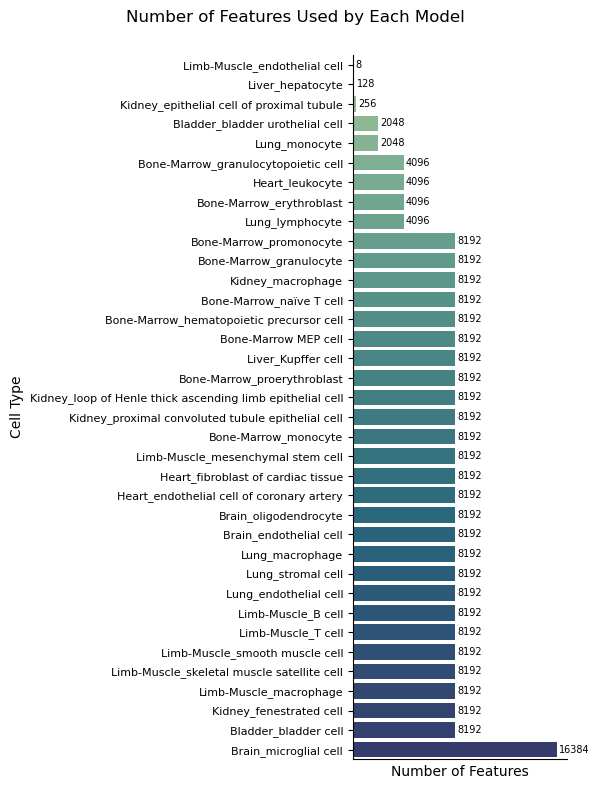

In [6]:
df_sorted = combined_df.sort_values("num_features", ascending=True)

plt.figure(figsize=(6, 8))  # height scales with number of cell types

ax = sns.barplot(
    data = df_sorted,
    x = "num_features",
    y = "experiment",
    hue = "experiment",
    palette="crest"
)
sns.despine(top=True, right=True, left=False, bottom=False)

ax.set_xlabel("Number of Features", fontsize = 10)
ax.set_ylabel("Cell Type", fontsize = 10)
plt.suptitle(
    "Number of Features Used by Each Model",
    fontsize=12,
    x=0.5,      
#     ha="center",
    y=0.98      
)

ax.tick_params(axis='y', labelsize=8)
ax.set_xticks([])

for i, value in enumerate(df_sorted["num_features"]):
    ax.text(value + max(df_sorted["num_features"]) * 0.01, i, str(value),
            va='center', ha='left', fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("./Figures/Feature_Count_by_celltype.png", dpi=600)
plt.show()